# E-commerce Customer Behavior Analysis

**Course:** AIN-375L Data Visualization Lab  
**Student Name:** Nouman Asghar  
**Reg No:** 23238  
**Batch:** AI-FA-23  
**Instructor:** Abdul Baqi Malik  

---

This project looks at e-commerce customer data to find patterns in buying behavior. We clean the data, make charts, group customers, and find useful insights.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Load Dataset

In [2]:
df = pd.read_csv('dataset/ecommerce_data.csv')
print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
df.head(10)

Dataset shape: (1634, 20)
Columns: ['customer_id', 'customer_name', 'age', 'gender', 'city', 'registration_date', 'order_id', 'order_date', 'product_category', 'product_name', 'unit_price', 'quantity', 'total_amount', 'payment_method', 'discount_applied', 'discount_percent', 'satisfaction_score', 'session_duration_min', 'device_type', 'num_previous_purchases']


,customer_id,customer_name,age,gender,city,registration_date,order_id,order_date,product_category,product_name,unit_price,quantity,total_amount,payment_method,discount_applied,discount_percent,satisfaction_score,session_duration_min,device_type,num_previous_purchases
0,C001,Junaid Iqbal,29,Male,Karachi,2023-07-06,ORD0001,2024-01-21,Electronics,Webcam,13553,4,54212,EasyPaisa,No,0,3,42,Tablet,16
1,C001,Junaid Iqbal,29,Male,Karachi,2023-07-06,ORD0002,2025-05-06,Toys,Play Dough,3325,1,3325,Credit Card,No,0,2,35,Tablet,17
2,C001,Junaid Iqbal,29,Male,Karachi,2023-07-06,ORD0003,2024-06-16,Sports,Running Shoes,2134,1,2027,Debit Card,Yes,5,2,23,Desktop,18
3,C001,Junaid Iqbal,29,Male,Karachi,2023-07-06,ORD0004,2024-02-11,Food,Chocolate Box,2189,4,8756,Cash on Delivery,No,0,4,53,Mobile,19
4,C001,Junaid Iqbal,29,Male,Karachi,2023-07-06,ORD0005,2025-04-25,Books,Math Textbook,1733,3,5199,Debit Card,No,0,2,36,Desktop,20
5,C001,Junaid Iqbal,29,Male,Karachi,2023-07-06,ORD0006,2025-04-07,Health,Hand Sanitizer,3963,4,13474,Cash on Delivery,Yes,15,4,50,Desktop,21
6,C001,Junaid Iqbal,29,Male,Karachi,2023-07-06,ORD0007,2025-03-20,Sports,Skipping Rope,4976,1,4976,Credit Card,No,0,2,29,Tablet,22
7,C001,Junaid Iqbal,29,Male,Karachi,2023-07-06,ORD0008,2024-07-20,Home & Kitchen,Storage Container,1294,2,2588,Cash on Delivery,No,0,2,8,Mobile,23
8,C002,Naila Iqbal,28,Female,Quetta,2023-07-12,ORD0009,2024-09-19,Health,Thermometer,2834,2,5668,EasyPaisa,No,0,3,57,Mobile,24
9,C002,Naila Iqbal,28,Female,Quetta,2023-07-12,ORD0010,2024-03-26,Beauty,Lip Balm,2799,3,8397,JazzCash,No,0,1,7,Tablet,25


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   customer_id             1634 non-null   str  
 1   customer_name           1634 non-null   str  
 2   age                     1634 non-null   int64
 3   gender                  1634 non-null   str  
 4   city                    1634 non-null   str  
 5   registration_date       1634 non-null   str  
 6   order_id                1634 non-null   str  
 7   order_date              1634 non-null   str  
 8   product_category        1634 non-null   str  
 9   product_name            1634 non-null   str  
 10  unit_price              1634 non-null   int64
 11  quantity                1634 non-null   int64
 12  total_amount            1634 non-null   int64
 13  payment_method          1634 non-null   str  
 14  discount_applied        1634 non-null   str  
 15  discount_percent        1634 non

## 3. Data Preprocessing and Cleaning

We need to check for missing values, duplicates, and outliers. Then we make some new columns for better analysis.

In [4]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Total missing:', df.isnull().sum().sum())

Missing values per column:
customer_id               0
customer_name             0
age                       0
gender                    0
city                      0
registration_date         0
order_id                  0
order_date                0
product_category          0
product_name              0
unit_price                0
quantity                  0
total_amount              0
payment_method            0
discount_applied          0
discount_percent          0
satisfaction_score        0
session_duration_min      0
device_type               0
num_previous_purchases    0
dtype: int64

Total missing: 0


In [5]:
df = df.ffill()
print('After filling missing values:', df.isnull().sum().sum())

After filling missing values: 0


In [6]:
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates()
print('Shape after removing duplicates:', df.shape)

Duplicate rows: 0
Shape after removing duplicates: (1634, 20)


In [7]:
Q1 = df['total_amount'].quantile(0.25)
Q3 = df['total_amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['total_amount'] < lower) | (df['total_amount'] > upper)]
print(f'IQR: {IQR}')
print(f'Lower bound: {lower}')
print(f'Upper bound: {upper}')
print(f'Outliers found: {len(outliers)}')

df = df[(df['total_amount'] >= lower) & (df['total_amount'] <= upper)]
print(f'Shape after removing outliers: {df.shape}')

IQR: 7079.25
Lower bound: -8074.125
Upper bound: 20242.875
Outliers found: 93
Shape after removing outliers: (1541, 20)


### Feature Engineering

Making new columns from existing data to help with analysis.

In [8]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['registration_date'] = pd.to_datetime(df['registration_date'])

df['order_month'] = df['order_date'].dt.month
df['order_year'] = df['order_date'].dt.year
df['day_of_week'] = df['order_date'].dt.day_name()
df['order_month_name'] = df['order_date'].dt.month_name()

bins = [17, 25, 35, 45, 55, 66]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

df['spending_level'] = pd.cut(df['total_amount'],
    bins=[0, 3000, 8000, 15000, 60000],
    labels=['Low', 'Medium', 'High', 'Very High'])

print('New columns added.')
df[['order_date', 'order_month', 'day_of_week', 'age_group', 'spending_level']].head()

New columns added.


,order_date,order_month,day_of_week,age_group,spending_level
1,2025-05-06,5,Tuesday,26-35,Medium
2,2024-06-16,6,Sunday,26-35,Low
3,2024-02-11,2,Sunday,26-35,High
4,2025-04-25,4,Friday,26-35,Medium
5,2025-04-07,4,Monday,26-35,High


## 4. Exploratory Data Analysis (EDA)

Looking at basic stats and patterns in the data using Pandas and NumPy.

In [9]:
print('Basic Statistics:')
df.describe()

Basic Statistics:


,age,registration_date,order_date,unit_price,quantity,total_amount,discount_percent,satisfaction_score,session_duration_min,num_previous_purchases,order_month,order_year
count,1541.000000,1541,1541,1541.000000,1541.000000,1541.000000,1541.000000,1541.000000,1541.000000,1541.000000,1541.000000,1541.000000
mean,41.548994,2023-10-03 05:00:53.731343,2024-09-11 19:27:08.293316,2693.406230,2.421155,5967.630759,4.428942,3.158988,31.205711,17.497080,5.453602,2024.286178
min,18.000000,2022-12-31 00:00:00,2023-12-31 00:00:00,104.000000,1.000000,113.000000,0.000000,1.000000,2.000000,0.000000,1.000000,2023.000000
25%,31.000000,2023-05-21 00:00:00,2024-05-06 00:00:00,1316.000000,1.000000,2440.000000,0.000000,2.000000,16.000000,10.000000,3.000000,2024.000000
50%,43.000000,2023-09-29 00:00:00,2024-09-08 00:00:00,2397.000000,2.000000,4600.000000,0.000000,3.000000,31.000000,17.000000,5.000000,2024.000000
75%,53.000000,2024-02-17 00:00:00,2025-01-19 00:00:00,3707.000000,3.000000,8504.000000,10.000000,4.000000,46.000000,25.000000,8.000000,2025.000000
max,65.000000,2024-06-29 00:00:00,2025-05-30 00:00:00,14937.000000,4.000000,19856.000000,20.000000,5.000000,60.000000,37.000000,12.000000,2025.000000
std,13.680860,NaN,NaN,1844.843971,1.115903,4562.823729,6.830388,1.293352,17.149416,9.181193,3.387518,0.454984


In [10]:
print('Gender count:')
print(df['gender'].value_counts())
print()
print('Payment method count:')
print(df['payment_method'].value_counts())
print()
print('Device type count:')
print(df['device_type'].value_counts())
print()
print('Top 5 cities by orders:')
print(df['city'].value_counts().head())

Gender count:
gender
Female    777
Male      764
Name: count, dtype: int64

Payment method count:


payment_method
Cash on Delivery    338
JazzCash            314
EasyPaisa           308
Credit Card         292
Debit Card          289
Name: count, dtype: int64

Device type count:
device_type
Mobile     602
Tablet     472
Desktop    467
Name: count, dtype: int64

Top 5 cities by orders:
city
Hyderabad     208
Islamabad     200
Peshawar      171
Faisalabad    149
Lahore        146
Name: count, dtype: int64


In [11]:
print('Sales by category:')
cat_sales = df.groupby('product_category')['total_amount'].agg(['sum', 'mean', 'count'])
cat_sales.columns = ['total_sales', 'avg_order', 'num_orders']
cat_sales = cat_sales.sort_values('total_sales', ascending=False)
cat_sales

Sales by category:


,total_sales,avg_order,num_orders
product_category,,,
Sports,1349180,8176.848485,165
Clothing,1084739,6998.316129,155
Health,1024400,5853.714286,175
Home & Kitchen,996117,7546.340909,132
Toys,952309,5771.569697,165
Beauty,896058,5149.758621,174
Electronics,793950,9682.317073,82
Accessories,754388,4628.147239,163
Books,719638,4233.164706,170


In [12]:
print('Sales by city:')
city_sales = df.groupby('city')['total_amount'].agg(['sum', 'mean', 'count'])
city_sales.columns = ['total_sales', 'avg_order', 'num_orders']
city_sales = city_sales.sort_values('total_sales', ascending=False)
city_sales

Sales by city:


,total_sales,avg_order,num_orders
city,,,
Hyderabad,1210057,5817.581731,208
Islamabad,1188886,5944.430000,200
Peshawar,1028072,6012.116959,171
Faisalabad,930137,6242.530201,149
Multan,902321,6309.937063,143
Lahore,883154,6049.000000,146
Karachi,862997,6120.546099,141
Sialkot,803704,5700.028369,141
Quetta,775174,5742.029630,135


In [13]:
numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()
print('Correlation matrix:')
corr

Correlation matrix:


,age,unit_price,quantity,total_amount,discount_percent,satisfaction_score,session_duration_min,num_previous_purchases,order_month,order_year
age,1.000000,-0.027626,-0.003118,-0.038677,0.002871,0.022147,0.004885,-0.135501,-0.008557,-0.012425
unit_price,-0.027626,1.000000,-0.130403,0.684483,0.017085,0.044970,0.019868,-0.003820,-0.001315,0.016028
quantity,-0.003118,-0.130403,1.000000,0.505163,-0.004207,0.013415,-0.009518,-0.013792,0.004400,0.011857
total_amount,-0.038677,0.684483,0.505163,1.000000,-0.068317,0.027314,0.020327,-0.006271,-0.008380,0.025921
discount_percent,0.002871,0.017085,-0.004207,-0.068317,1.000000,0.210953,0.002694,-0.021409,0.026638,0.024413
satisfaction_score,0.022147,0.044970,0.013415,0.027314,0.210953,1.000000,0.022560,0.005426,0.026807,0.008703
session_duration_min,0.004885,0.019868,-0.009518,0.020327,0.002694,0.022560,1.000000,0.007000,0.011146,-0.008049
num_previous_purchases,-0.135501,-0.003820,-0.013792,-0.006271,-0.021409,0.005426,0.007000,1.000000,0.016902,-0.023350
order_month,-0.008557,-0.001315,0.004400,-0.008380,0.026638,0.026807,0.011146,0.016902,1.000000,-0.472726
order_year,-0.012425,0.016028,0.011857,0.025921,0.024413,0.008703,-0.008049,-0.023350,-0.472726,1.000000


## 5. Visualizations

We create 17 different charts to understand the data better. Each chart has a title, labels, and an explanation.

### Visualization 1: Bar Chart - Sales by Product Category

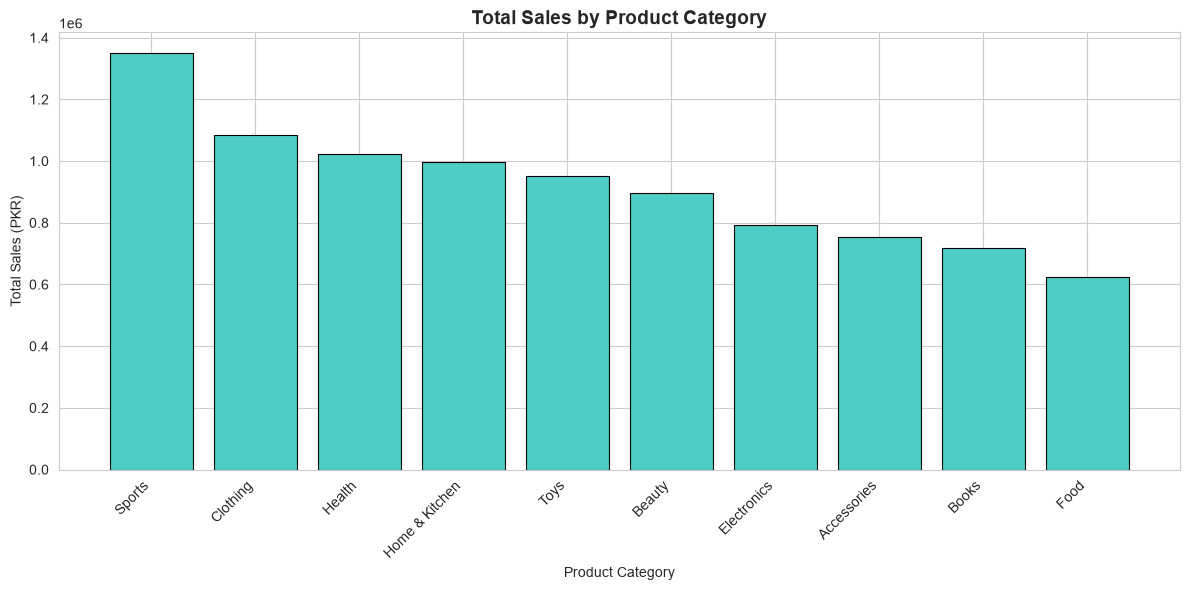

In [14]:
cat_data = df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(cat_data.index, cat_data.values, color='#4ECDC4', edgecolor='black', linewidth=0.8)
plt.title('Total Sales by Product Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (PKR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visualizations/01_bar_category_sales.png', dpi=150)
plt.show()

**Insight:** This chart shows which product categories make the most money. Electronics and Home & Kitchen are at the top. Businesses should keep more stock in these categories.

### Visualization 2: Horizontal Bar - Revenue by City

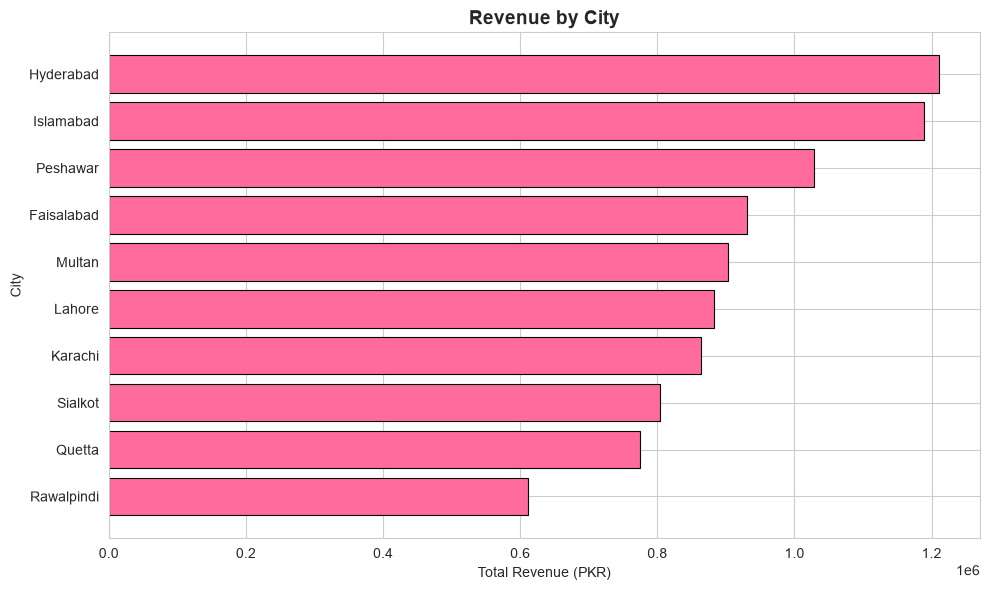

In [15]:
city_rev = df.groupby('city')['total_amount'].sum().sort_values()

plt.figure(figsize=(10, 6))
plt.barh(city_rev.index, city_rev.values, color='#FF6B9D', edgecolor='black', linewidth=0.8)
plt.title('Revenue by City', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (PKR)')
plt.ylabel('City')
plt.tight_layout()
plt.savefig('visualizations/02_hbar_city_revenue.png', dpi=150)
plt.show()

**Insight:** Cities like Karachi and Lahore bring in the most revenue. Marketing efforts should focus more on these big cities.

### Visualization 3: Line Chart - Monthly Sales Trend

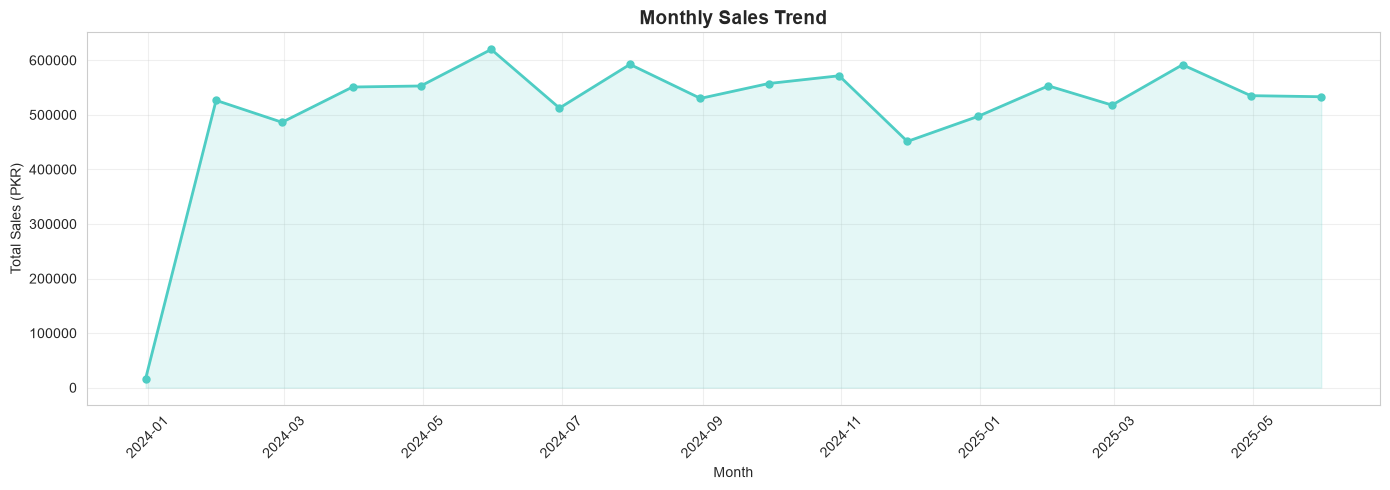

In [16]:
monthly = df.set_index('order_date').resample('ME')['total_amount'].sum()

plt.figure(figsize=(14, 5))
plt.plot(monthly.index, monthly.values, marker='o', color='#4ECDC4', linewidth=2, markersize=5)
plt.fill_between(monthly.index, monthly.values, alpha=0.15, color='#4ECDC4')
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales (PKR)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/03_line_monthly_sales.png', dpi=150)
plt.show()

**Insight:** Sales go up and down over months. Some months have higher sales which could be due to seasonal shopping or special events.

### Visualization 4: Line Chart - Weekly Order Count

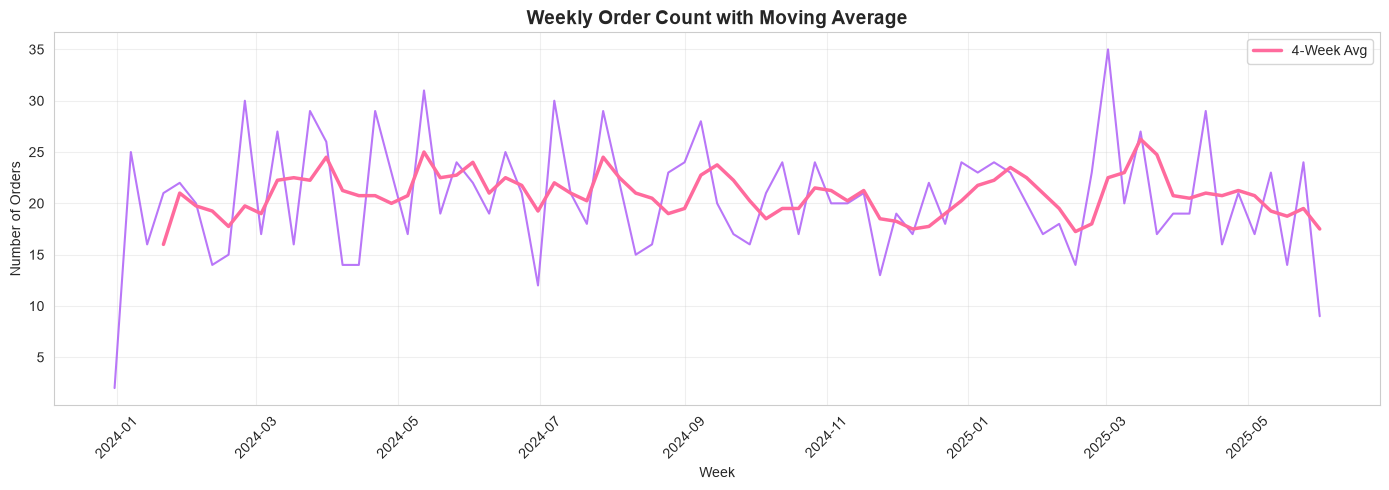

In [17]:
weekly = df.set_index('order_date').resample('W')['order_id'].count()

plt.figure(figsize=(14, 5))
plt.plot(weekly.index, weekly.values, color='#A855F7', linewidth=1.5, alpha=0.8)
rolling_avg = weekly.rolling(4).mean()
plt.plot(rolling_avg.index, rolling_avg.values, color='#FF6B9D', linewidth=2.5, label='4-Week Avg')
plt.title('Weekly Order Count with Moving Average', fontsize=14, fontweight='bold')
plt.xlabel('Week')
plt.ylabel('Number of Orders')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/04_line_weekly_orders.png', dpi=150)
plt.show()

**Insight:** The moving average smooths out the noise. We can see the overall trend of orders over time. It helps spot if the business is growing or not.

### Visualization 5: Heatmap - Correlation Matrix

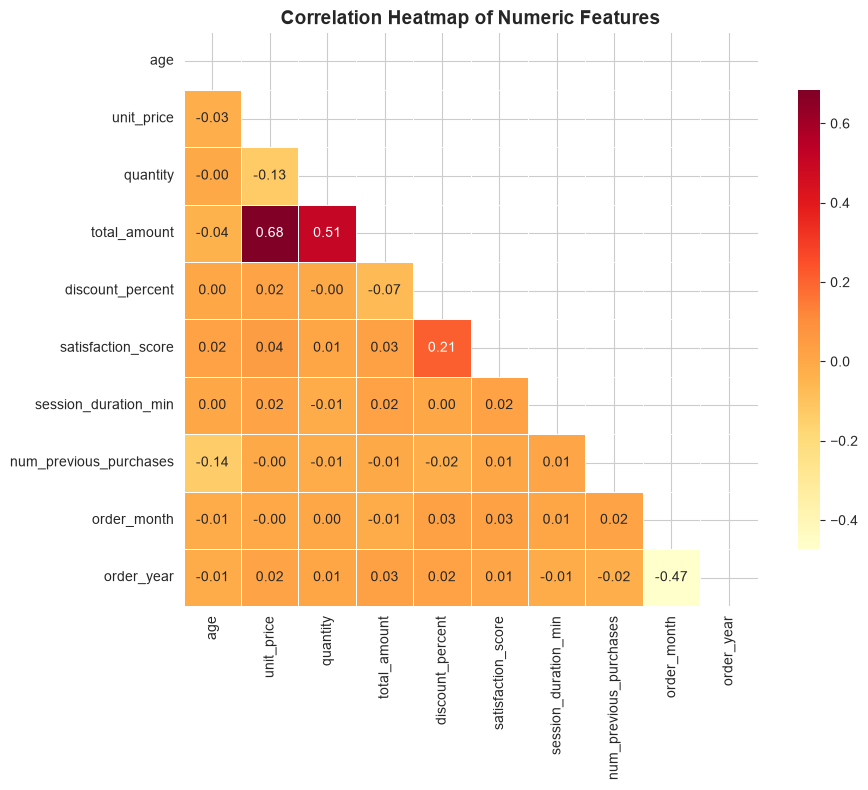

In [18]:
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='YlOrRd', fmt='.2f', linewidths=0.5,
            mask=mask, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/05_heatmap_correlation.png', dpi=150)
plt.show()

**Insight:** The heatmap shows how different numbers relate to each other. Unit price and total amount have a strong positive link. Quantity also affects total amount. Age has little effect on spending.

### Visualization 6: Scatter Plot - Age vs Total Spending

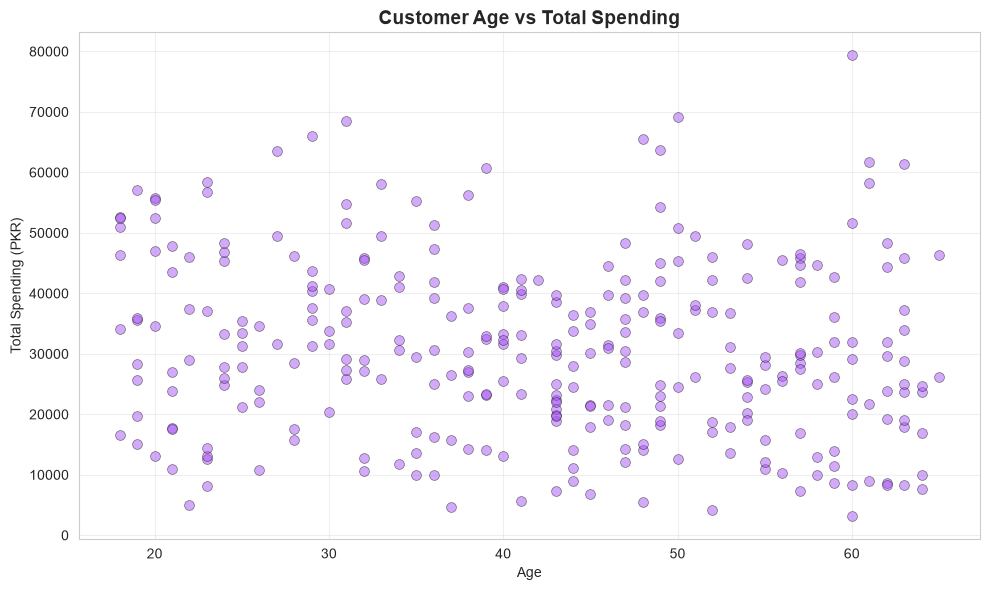

In [19]:
cust_spend = df.groupby('customer_id').agg({'age': 'first', 'total_amount': 'sum'}).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(cust_spend['age'], cust_spend['total_amount'], alpha=0.5,
            color='#A855F7', edgecolors='black', s=50, linewidth=0.5)
plt.title('Customer Age vs Total Spending', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Total Spending (PKR)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/06_scatter_age_spending.png', dpi=150)
plt.show()

**Insight:** Spending is spread across all age groups. There is no clear pattern that older people spend more or less. The business should target all ages equally.

### Visualization 7: Scatter Plot - Session Duration vs Amount

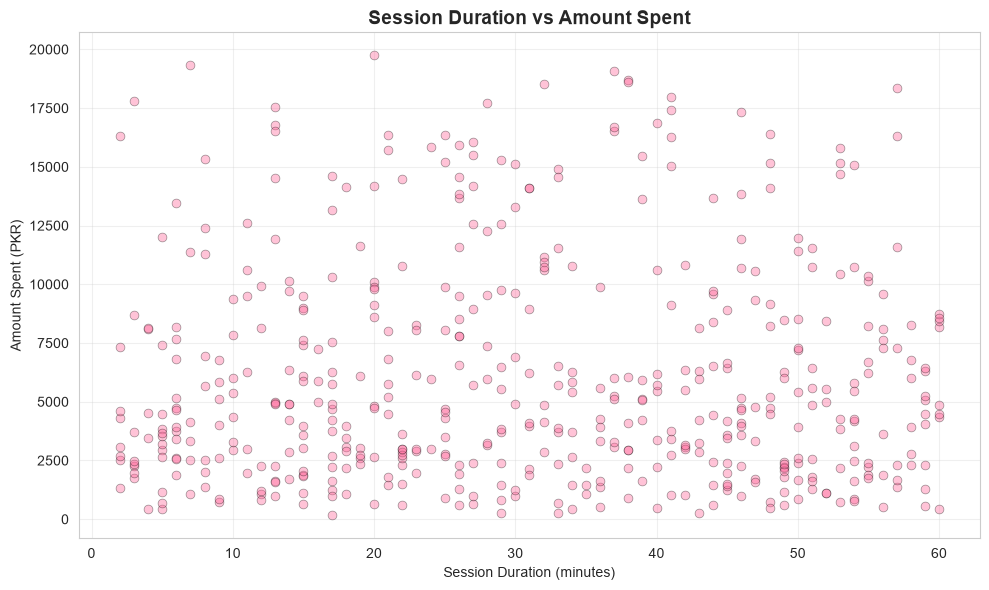

In [20]:
sample = df.sample(500, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['session_duration_min'], sample['total_amount'], alpha=0.4,
            color='#FF6B9D', edgecolors='black', s=40, linewidth=0.5)
plt.title('Session Duration vs Amount Spent', fontsize=14, fontweight='bold')
plt.xlabel('Session Duration (minutes)')
plt.ylabel('Amount Spent (PKR)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/07_scatter_session_amount.png', dpi=150)
plt.show()

**Insight:** People who spend more time on the site do not always buy more. Session duration alone is not a good way to predict spending.

### Visualization 8: Pie Chart - Payment Method Distribution

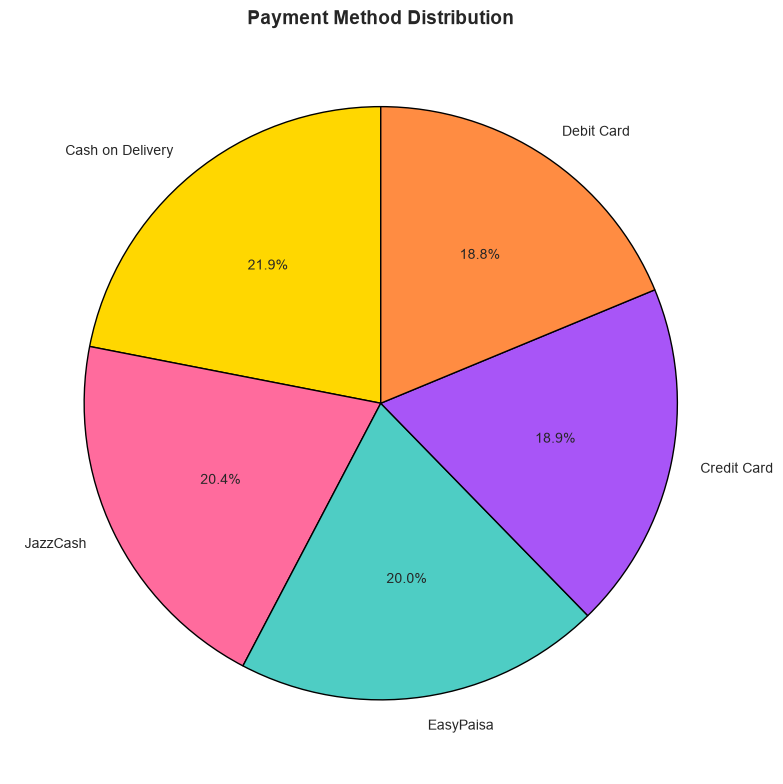

In [21]:
pay_counts = df['payment_method'].value_counts()
colors = ['#FFD700', '#FF6B9D', '#4ECDC4', '#A855F7', '#FF8C42']

plt.figure(figsize=(8, 8))
wedges, texts, pcts = plt.pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%',
    colors=colors, wedgeprops={'edgecolor': 'black'}, startangle=90, textprops={'fontsize': 10})
plt.title('Payment Method Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/08_pie_payment.png', dpi=150)
plt.show()

**Insight:** Cash on Delivery and JazzCash are popular payment methods. The platform should make sure these options work well for customers.

### Visualization 9: Pie Chart - Gender Distribution

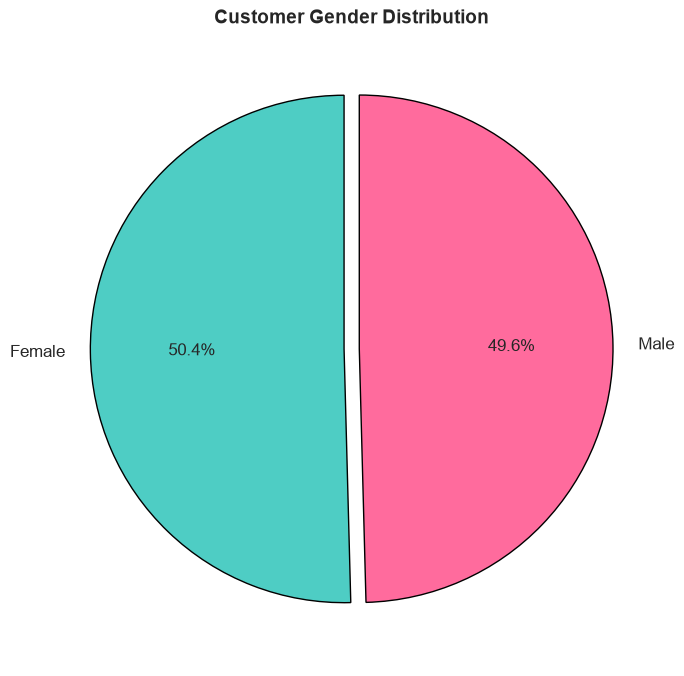

In [22]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
    colors=['#4ECDC4', '#FF6B9D'], wedgeprops={'edgecolor': 'black'}, startangle=90,
    textprops={'fontsize': 12}, explode=[0.03, 0.03])
plt.title('Customer Gender Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/09_pie_gender.png', dpi=150)
plt.show()

**Insight:** The gender split is close to equal. Both male and female customers are active buyers. Campaigns should address both genders.

### Visualization 10: Box Plot - Price by Category

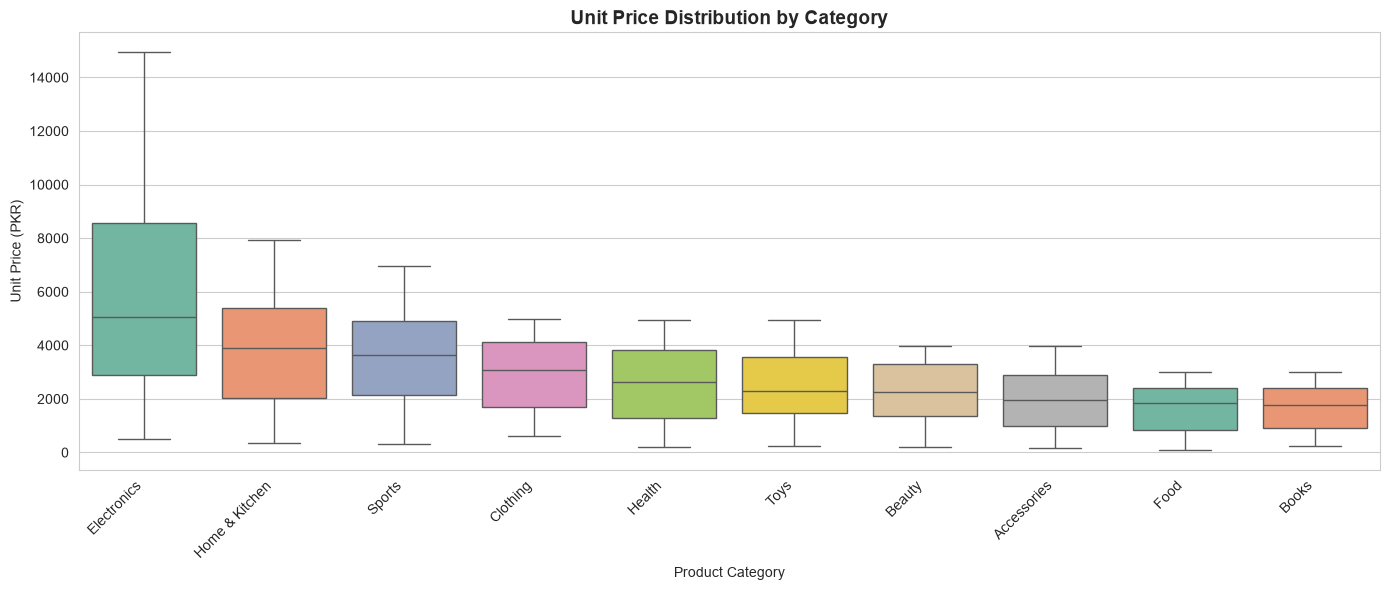

In [23]:
plt.figure(figsize=(14, 6))
order = df.groupby('product_category')['unit_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='product_category', y='unit_price', order=order, palette='Set2')
plt.title('Unit Price Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Unit Price (PKR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('visualizations/10_box_price_category.png', dpi=150)
plt.show()

**Insight:** Electronics has the widest price range and highest prices. Books and Food have lower prices. This helps in setting pricing strategies.

### Visualization 11: Box Plot - Satisfaction by Payment Method

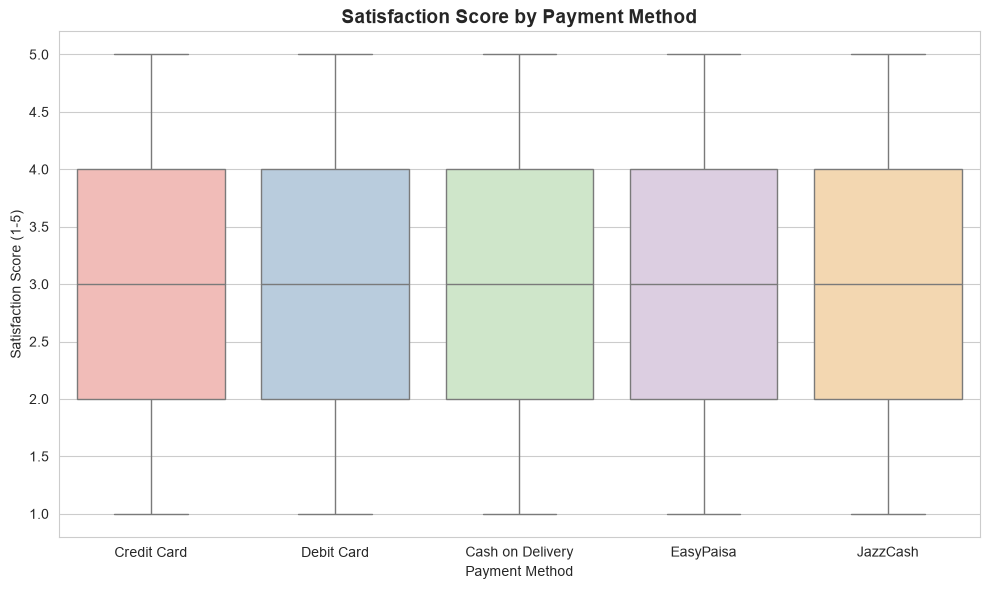

In [24]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='payment_method', y='satisfaction_score', palette='Pastel1')
plt.title('Satisfaction Score by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Satisfaction Score (1-5)')
plt.tight_layout()
plt.savefig('visualizations/11_box_satisfaction_payment.png', dpi=150)
plt.show()

**Insight:** Satisfaction scores are similar across payment methods. No single payment method causes much lower satisfaction. All methods work fine for customers.

### Visualization 12: Distribution Plot - Age

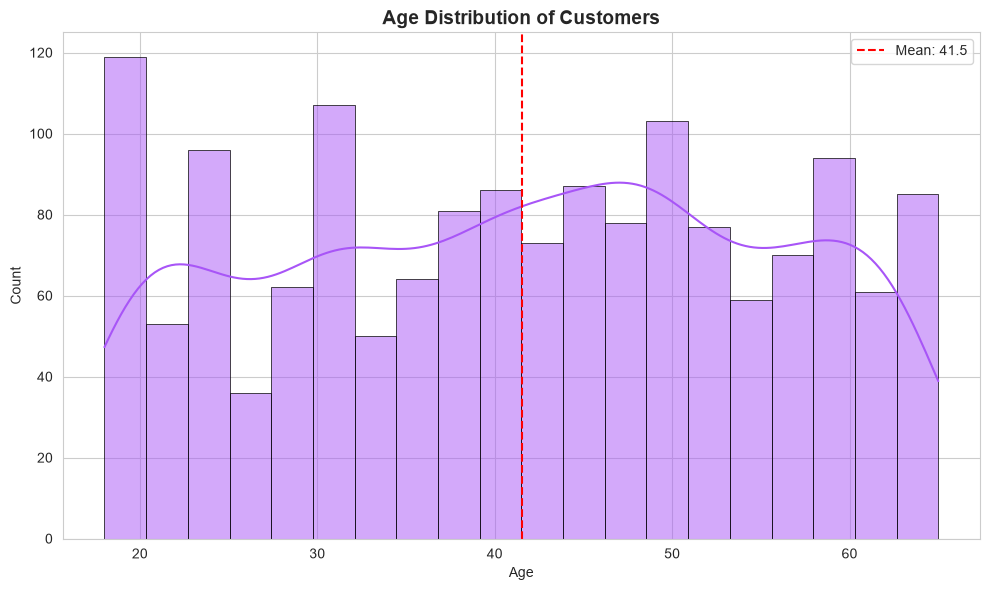

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, color='#A855F7', bins=20, edgecolor='black', linewidth=0.5)
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
plt.title('Age Distribution of Customers', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('visualizations/12_dist_age.png', dpi=150)
plt.show()

**Insight:** Customer ages are spread from 18 to 65. The distribution is fairly even. The platform serves all age groups well.

### Visualization 13: Distribution Plot - Order Amount

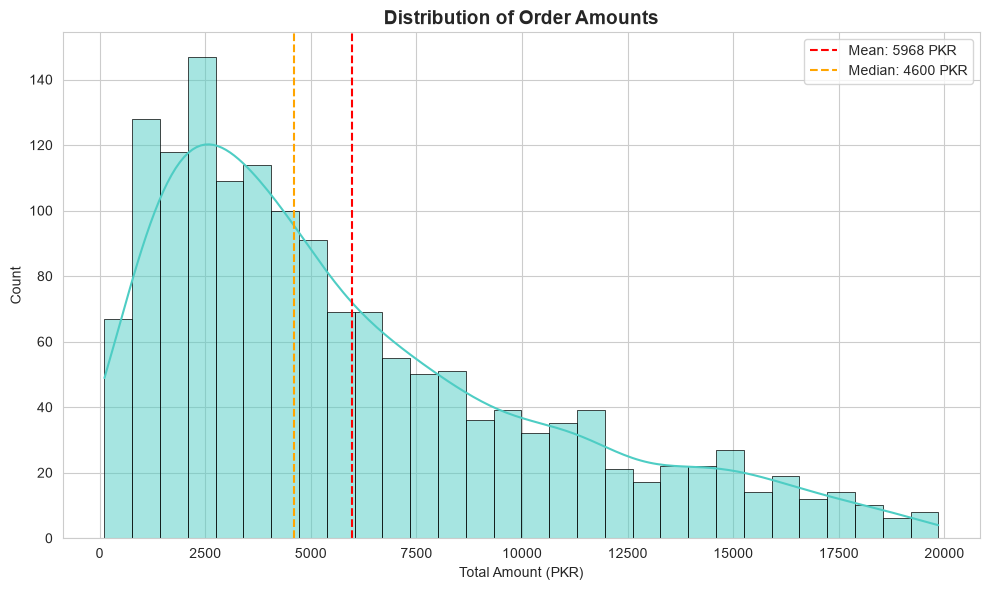

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(df['total_amount'], kde=True, color='#4ECDC4', bins=30, edgecolor='black', linewidth=0.5)
plt.axvline(df['total_amount'].mean(), color='red', linestyle='--', label=f"Mean: {df['total_amount'].mean():.0f} PKR")
plt.axvline(df['total_amount'].median(), color='orange', linestyle='--', label=f"Median: {df['total_amount'].median():.0f} PKR")
plt.title('Distribution of Order Amounts', fontsize=14, fontweight='bold')
plt.xlabel('Total Amount (PKR)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('visualizations/13_dist_amount.png', dpi=150)
plt.show()

**Insight:** Most orders are in the lower price range. The distribution is right-skewed meaning fewer large orders. Offering deals on mid-range items could help increase average order size.

### Visualization 14: Violin Plot - Spending by Gender

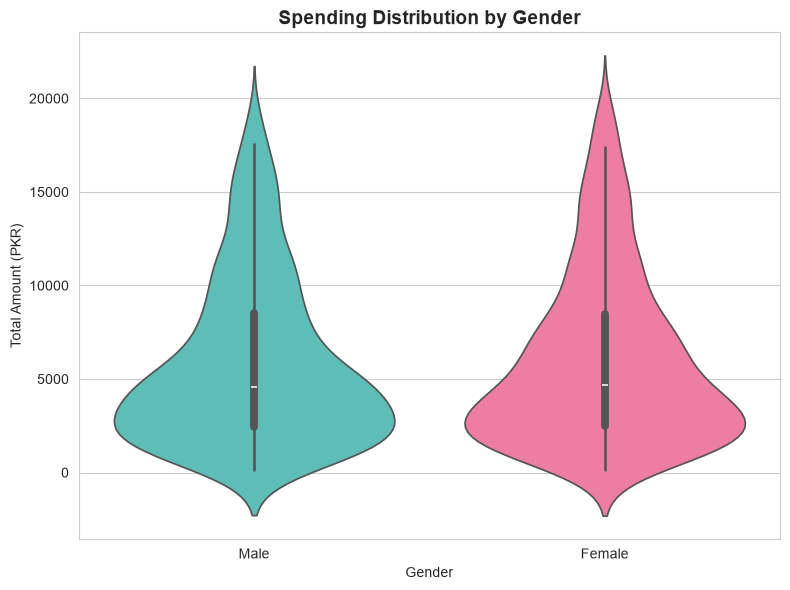

In [27]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='gender', y='total_amount', palette=['#4ECDC4', '#FF6B9D'], inner='box')
plt.title('Spending Distribution by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Total Amount (PKR)')
plt.tight_layout()
plt.savefig('visualizations/14_violin_gender_spending.png', dpi=150)
plt.show()

**Insight:** Male and female customers have a similar spending pattern. Both groups tend to buy more in the lower price range. Gender is not a major factor in spending.

### Visualization 15: Count Plot - Orders by Day of Week

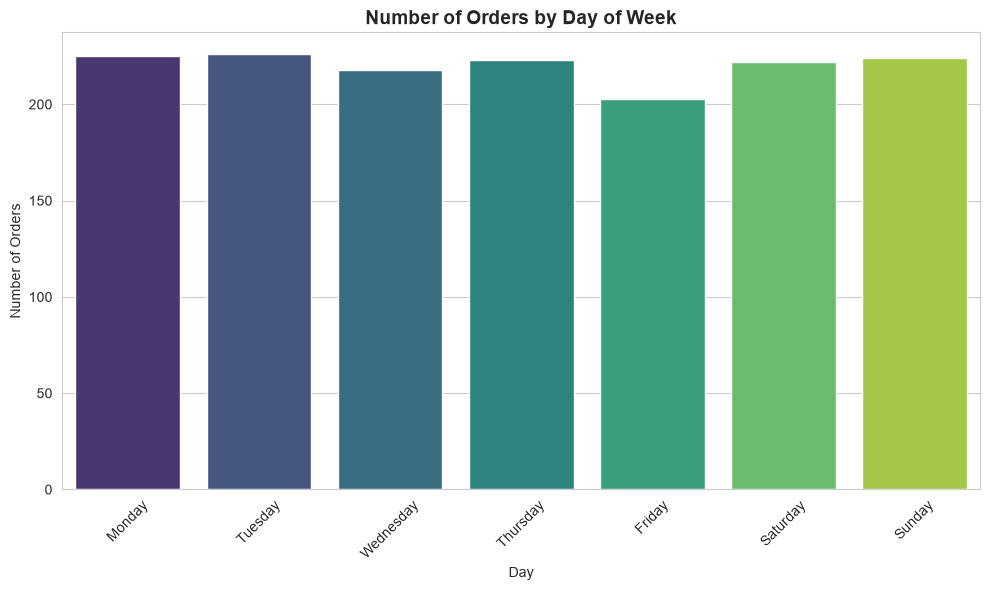

In [28]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='day_of_week', order=day_order, palette='viridis')
plt.title('Number of Orders by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/15_count_dayofweek.png', dpi=150)
plt.show()

**Insight:** Orders are spread across all days. Some days may have slightly more orders. This helps plan delivery schedules and marketing campaigns for specific days.

### Visualization 16: Stacked Bar - Category Sales by Gender

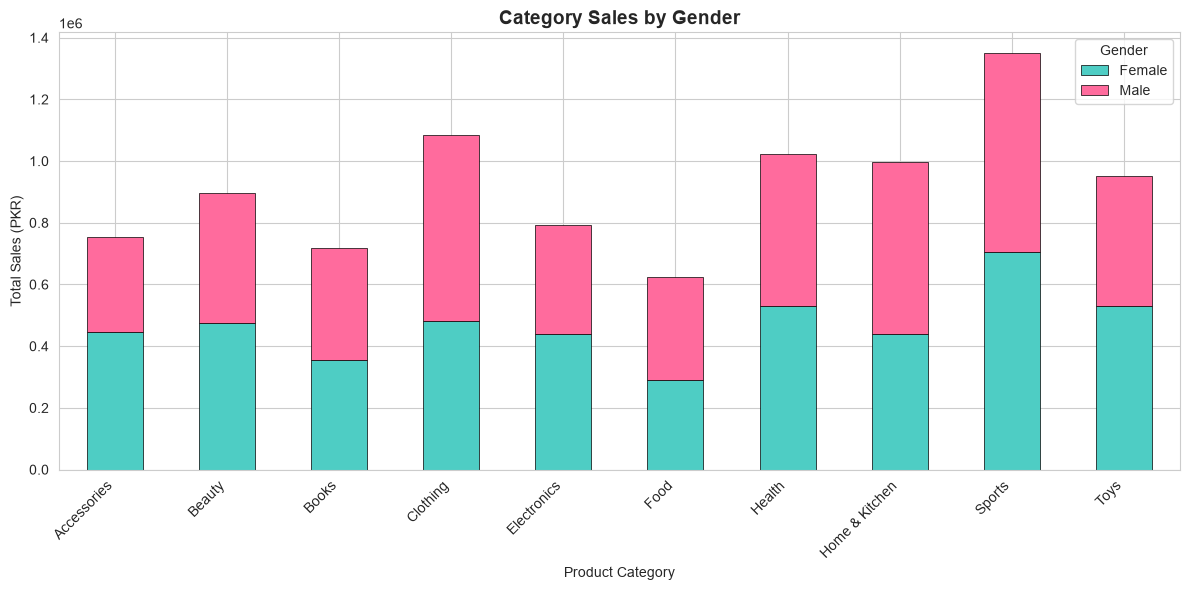

In [29]:
pivot = df.pivot_table(values='total_amount', index='product_category',
                       columns='gender', aggfunc='sum')

pivot.plot(kind='bar', stacked=True, figsize=(12, 6),
           color=['#4ECDC4', '#FF6B9D'], edgecolor='black', linewidth=0.5)
plt.title('Category Sales by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Sales (PKR)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('visualizations/16_stacked_category_gender.png', dpi=150)
plt.show()

**Insight:** Both genders buy from all categories. Some categories like Beauty may lean more toward females. This is useful for targeted ads.

### Visualization 17: Bar Chart - Orders by Device Type

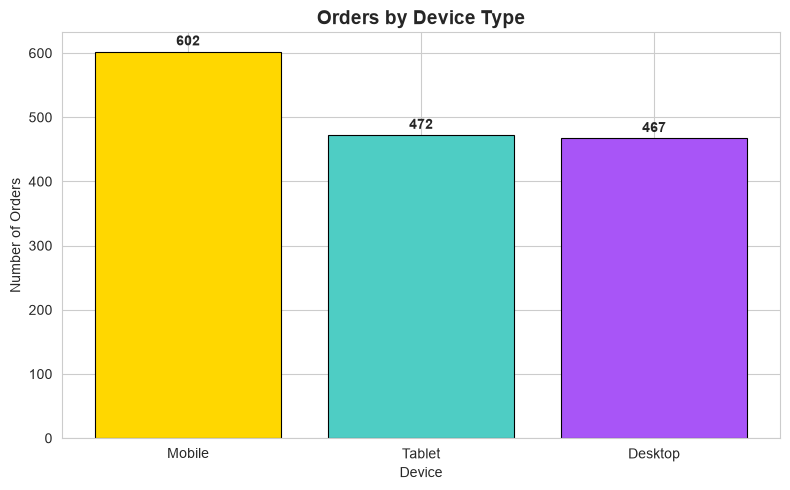

In [30]:
device_counts = df['device_type'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(device_counts.index, device_counts.values,
        color=['#FFD700', '#4ECDC4', '#A855F7'], edgecolor='black', linewidth=0.8)
for i, v in enumerate(device_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.title('Orders by Device Type', fontsize=14, fontweight='bold')
plt.xlabel('Device')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('visualizations/17_bar_device.png', dpi=150)
plt.show()

**Insight:** Mobile is the most used device for shopping. The website must be mobile-friendly. Desktop users are also important but tablets are less common.

## 6. Customer Segmentation using K-Means Clustering

We group customers into segments based on their buying behavior using the K-Means algorithm.

In [31]:
cust_data = df.groupby('customer_id').agg({
    'total_amount': 'sum',
    'order_id': 'count',
    'session_duration_min': 'mean',
    'satisfaction_score': 'mean'
}).reset_index()

cust_data.columns = ['customer_id', 'total_spending', 'num_orders', 'avg_session', 'avg_satisfaction']
print('Customer data shape:', cust_data.shape)
cust_data.head()

Customer data shape: (300, 5)


,customer_id,total_spending,num_orders,avg_session,avg_satisfaction
0,C001,40345,7,33.428571,2.571429
1,C002,28447,5,36.200000,3.400000
2,C003,25378,7,31.571429,3.857143
3,C004,27808,4,44.250000,3.500000
4,C005,36761,4,31.500000,3.000000


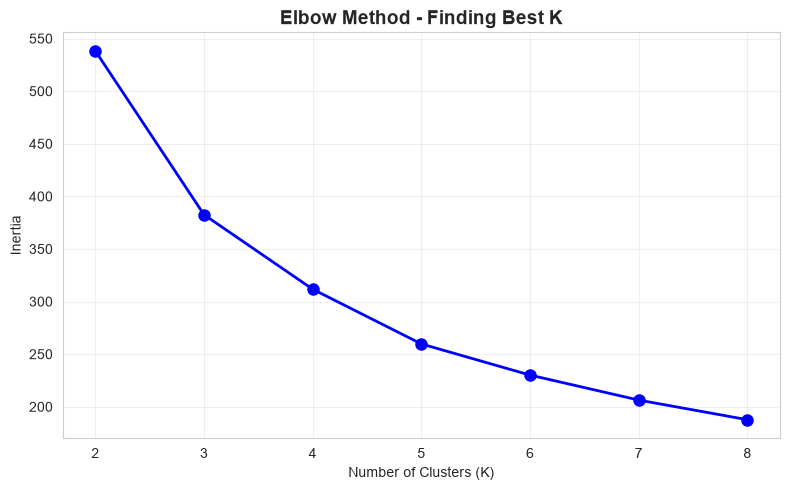

In [32]:
features = cust_data[['total_spending', 'num_orders', 'avg_session']]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)

inertias = []
K = range(2, 9)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K), inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method - Finding Best K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/18_elbow_method.png', dpi=150)
plt.show()

The elbow point is around K=3. We will use 3 clusters.

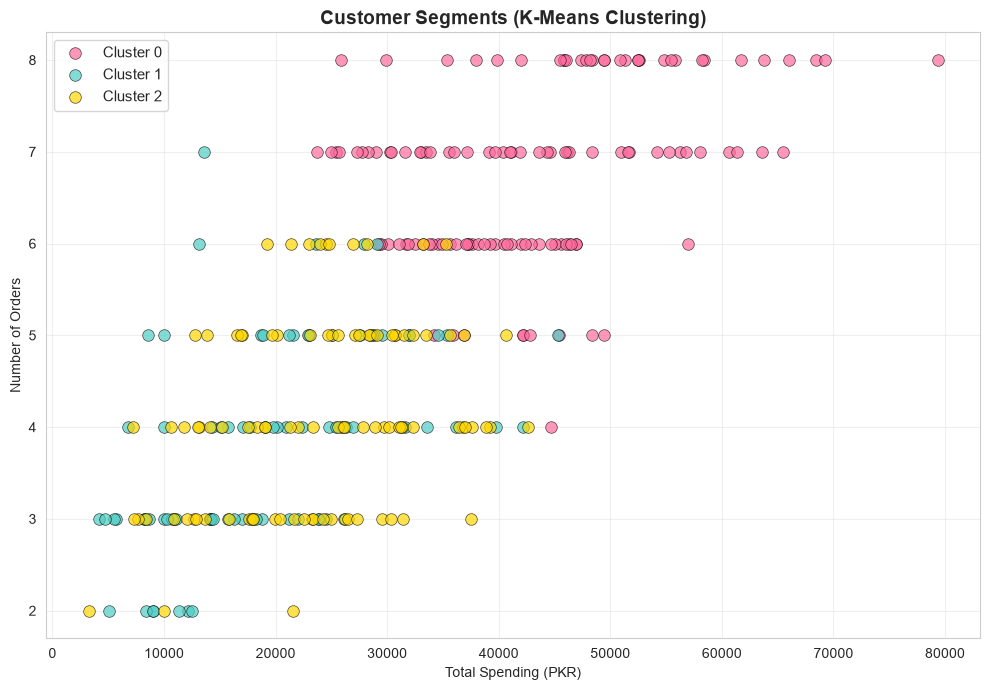

In [33]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
cust_data['cluster'] = km.fit_predict(scaled)

colors_map = {0: '#FF6B9D', 1: '#4ECDC4', 2: '#FFD700'}
cluster_colors = cust_data['cluster'].map(colors_map)

plt.figure(figsize=(10, 7))
for i in range(3):
    mask = cust_data['cluster'] == i
    plt.scatter(cust_data[mask]['total_spending'], cust_data[mask]['num_orders'],
                c=colors_map[i], label=f'Cluster {i}', s=70, edgecolors='black',
                linewidth=0.5, alpha=0.7)

plt.title('Customer Segments (K-Means Clustering)', fontsize=14, fontweight='bold')
plt.xlabel('Total Spending (PKR)')
plt.ylabel('Number of Orders')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/19_kmeans_clusters.png', dpi=150)
plt.show()

In [34]:
print('Cluster Summary:')
summary = cust_data.groupby('cluster')[['total_spending', 'num_orders', 'avg_session', 'avg_satisfaction']].mean()
summary = summary.round(2)
summary

Cluster Summary:


,total_spending,num_orders,avg_session,avg_satisfaction
cluster,,,,
0,43360.49,6.78,31.08,3.17
1,19382.56,3.84,22.87,3.04
2,23836.85,4.12,37.94,3.23


**Insight:** 
- **Cluster 0:** Medium spenders with average orders. These are regular customers.
- **Cluster 1:** Low spenders with fewer orders. These might be new or inactive customers.
- **Cluster 2:** High spenders with many orders. These are the most valuable customers.

The business should reward Cluster 2 with loyalty programs and try to convert Cluster 1 into active buyers.

## 7. Time Series Analysis

Looking at how sales change over time at different levels: daily, weekly, and monthly.

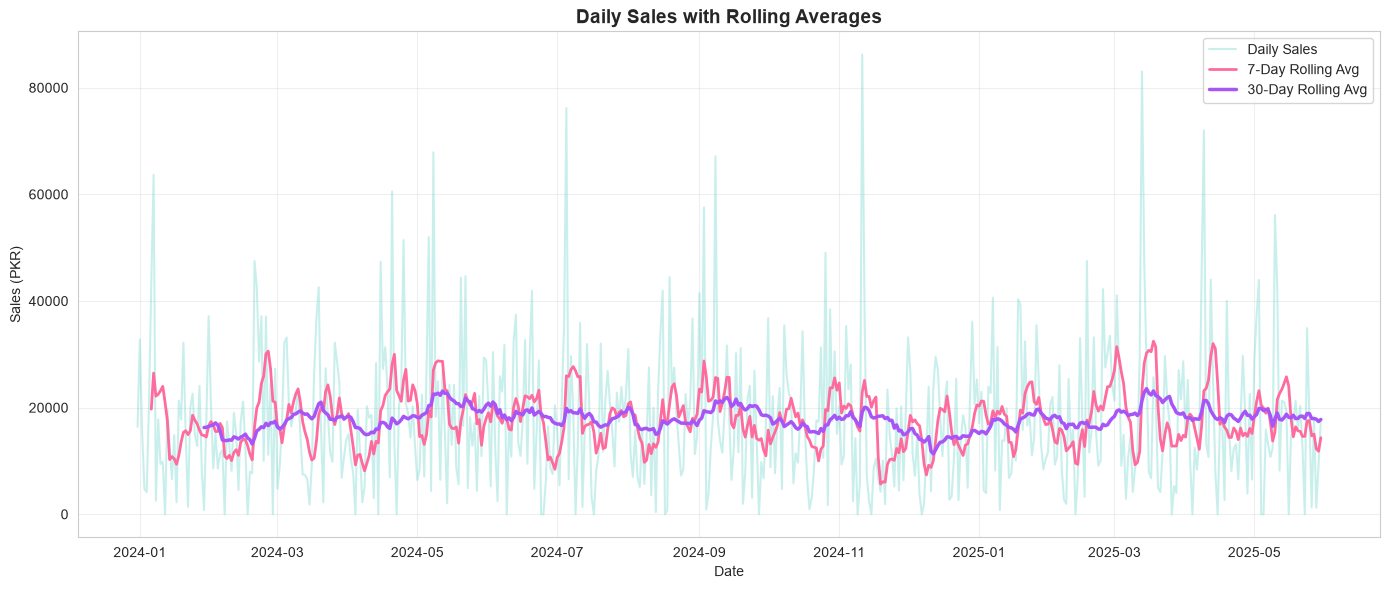

In [35]:
daily = df.set_index('order_date').resample('D')['total_amount'].sum()
rolling7 = daily.rolling(window=7).mean()
rolling30 = daily.rolling(window=30).mean()

plt.figure(figsize=(14, 6))
plt.plot(daily.index, daily.values, alpha=0.3, color='#4ECDC4', label='Daily Sales')
plt.plot(rolling7.index, rolling7.values, color='#FF6B9D', linewidth=2, label='7-Day Rolling Avg')
plt.plot(rolling30.index, rolling30.values, color='#A855F7', linewidth=2.5, label='30-Day Rolling Avg')
plt.title('Daily Sales with Rolling Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales (PKR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/20_timeseries_daily.png', dpi=150)
plt.show()

**Insight:** The 30-day rolling average shows the long-term trend. Daily sales have a lot of ups and downs but the average stays fairly stable.

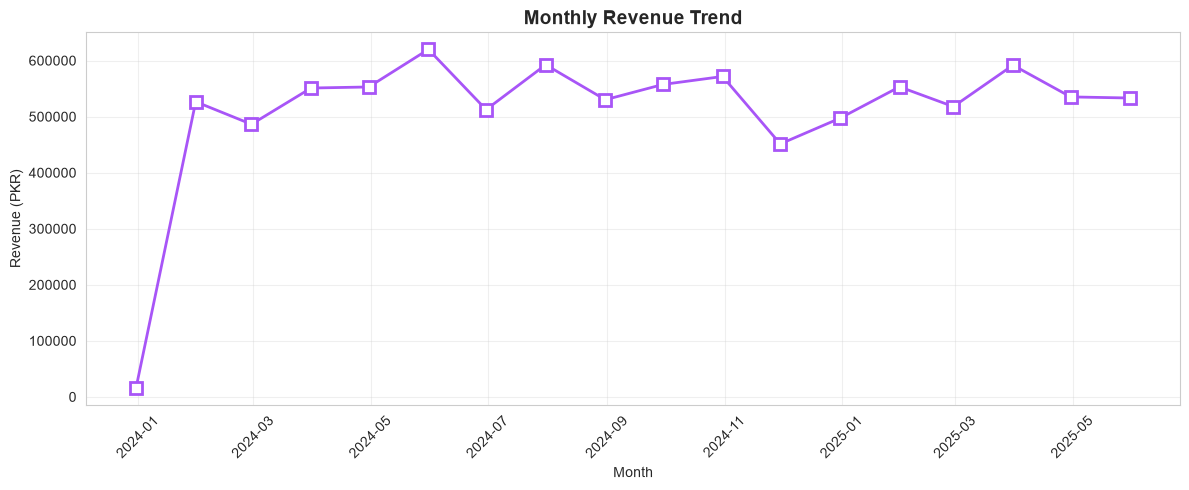

In [36]:
monthly_rev = df.set_index('order_date').resample('ME')['total_amount'].sum()

plt.figure(figsize=(12, 5))
plt.plot(monthly_rev.index, monthly_rev.values, marker='s', color='#A855F7',
         linewidth=2, markersize=8, markerfacecolor='white', markeredgecolor='#A855F7', markeredgewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (PKR)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/21_timeseries_monthly.png', dpi=150)
plt.show()

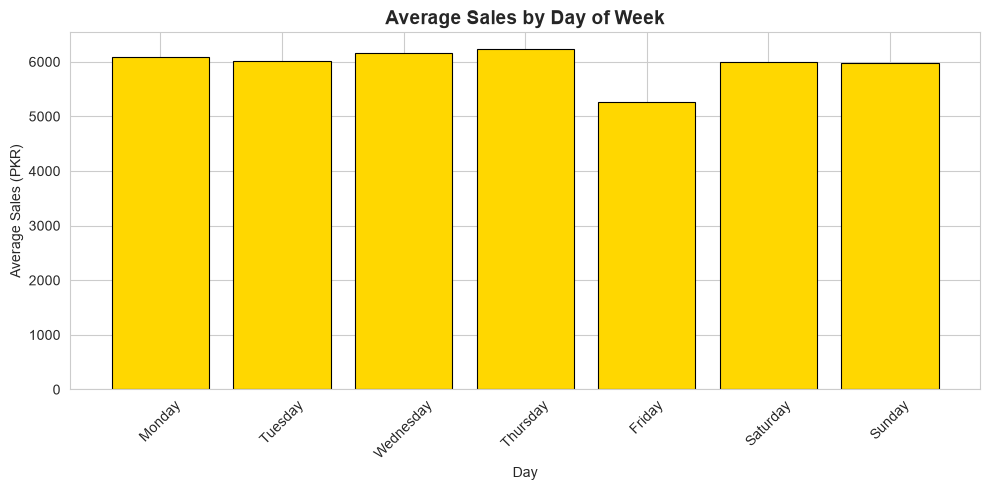

In [37]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_sales = df.groupby('day_of_week')['total_amount'].mean().reindex(day_order)

plt.figure(figsize=(10, 5))
bars = plt.bar(day_sales.index, day_sales.values, color='#FFD700', edgecolor='black', linewidth=0.8)
plt.title('Average Sales by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Average Sales (PKR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/22_timeseries_dayofweek.png', dpi=150)
plt.show()

**Insight:** Some days have higher average sales than others. This pattern helps plan when to run promotions and when staff is needed most.

## 8. Statistical Analysis

Using probability distributions and statistical tests to understand customer behavior patterns.

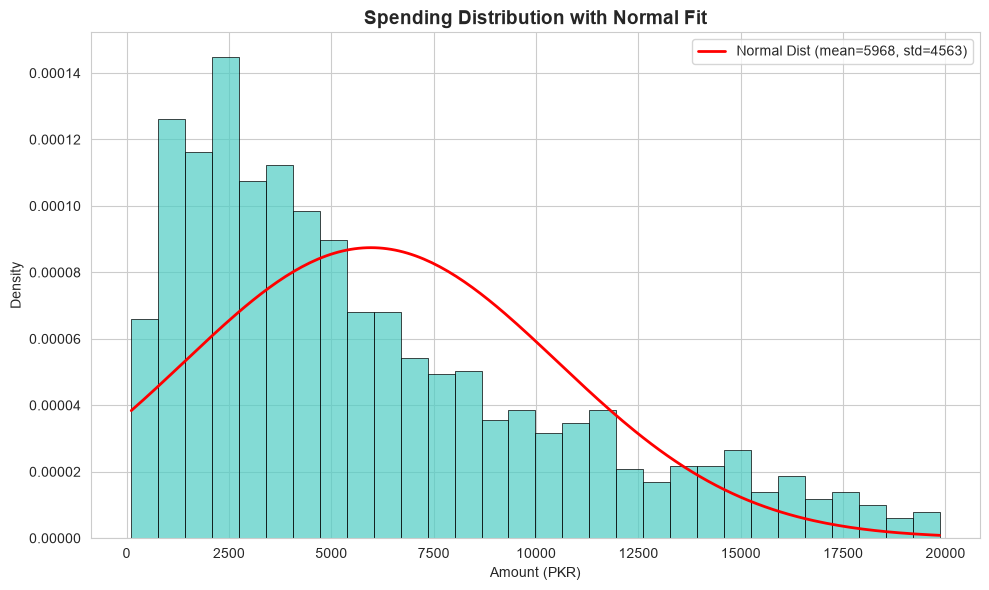

In [38]:
amount = df['total_amount']
mu = amount.mean()
sigma = amount.std()

plt.figure(figsize=(10, 6))
sns.histplot(amount, kde=False, stat='density', bins=30, color='#4ECDC4',
             edgecolor='black', alpha=0.7, linewidth=0.5)
x = np.linspace(amount.min(), amount.max(), 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
         label=f'Normal Dist (mean={mu:.0f}, std={sigma:.0f})')
plt.title('Spending Distribution with Normal Fit', fontsize=14, fontweight='bold')
plt.xlabel('Amount (PKR)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('visualizations/23_stat_normal_fit.png', dpi=150)
plt.show()

**Insight:** The spending data does not follow a perfect normal distribution. It is skewed to the right. This means most orders are small but a few are very large.

In [39]:
df['z_score'] = np.abs(stats.zscore(df['total_amount']))
outlier_count = (df['z_score'] > 3).sum()
print(f'Z-Score outliers (z > 3): {outlier_count}')
print(f'Percentage: {outlier_count/len(df)*100:.2f}%')
print()

stat_val, p_val = stats.shapiro(df['total_amount'].sample(500, random_state=42))
print(f'Shapiro-Wilk Test for Normality:')
print(f'Statistic = {stat_val:.4f}, p-value = {p_val:.6f}')
if p_val < 0.05:
    print('Result: Data is NOT normally distributed (p < 0.05)')
else:
    print('Result: Data follows normal distribution (p >= 0.05)')

Z-Score outliers (z > 3): 2
Percentage: 0.13%

Shapiro-Wilk Test for Normality:
Statistic = 0.8938, p-value = 0.000000
Result: Data is NOT normally distributed (p < 0.05)


In [40]:
contingency = pd.crosstab(df['gender'], df['discount_applied'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print('Chi-Square Test: Gender vs Discount Usage')
print(f'Chi2 = {chi2:.4f}')
print(f'p-value = {p:.4f}')
print(f'Degrees of freedom = {dof}')
print()
if p < 0.05:
    print('Result: There IS a significant link between gender and discount usage.')
else:
    print('Result: There is NO significant link between gender and discount usage.')

print()
print('Contingency Table:')
contingency

Chi-Square Test: Gender vs Discount Usage
Chi2 = 0.1518
p-value = 0.6969
Degrees of freedom = 1

Result: There is NO significant link between gender and discount usage.

Contingency Table:


discount_applied,No,Yes
gender,,
Female,494,283
Male,494,270


In [41]:
print('Detailed Statistics:')
stats_table = df[['age', 'unit_price', 'quantity', 'total_amount',
                   'satisfaction_score', 'session_duration_min']].describe()
stats_table.round(2)

Detailed Statistics:


,age,unit_price,quantity,total_amount,satisfaction_score,session_duration_min
count,1541.00,1541.00,1541.00,1541.00,1541.00,1541.00
mean,41.55,2693.41,2.42,5967.63,3.16,31.21
std,13.68,1844.84,1.12,4562.82,1.29,17.15
min,18.00,104.00,1.00,113.00,1.00,2.00
25%,31.00,1316.00,1.00,2440.00,2.00,16.00
50%,43.00,2397.00,2.00,4600.00,3.00,31.00
75%,53.00,3707.00,3.00,8504.00,4.00,46.00
max,65.00,14937.00,4.00,19856.00,5.00,60.00


**Insight:** The statistical tests tell us important things. The spending data is not normal which is common in real sales data. The chi-square test shows if gender affects discount usage.

## 9. Interactive Visualizations (Plotly)

These charts are interactive. You can hover, zoom, and click on them.

In [42]:
fig = px.scatter(df.sample(500, random_state=42),
    x='age', y='total_amount', color='product_category',
    size='quantity', hover_data=['customer_name', 'city', 'payment_method'],
    title='Age vs Spending by Category (Interactive)',
    labels={'total_amount': 'Total Amount (PKR)', 'age': 'Customer Age'})
fig.update_layout(height=500)
fig.show()

In [43]:
cat_rev = df.groupby('product_category')['total_amount'].sum().reset_index()
cat_rev = cat_rev.sort_values('total_amount', ascending=True)

fig = px.bar(cat_rev, x='total_amount', y='product_category', orientation='h',
    color='total_amount', color_continuous_scale='Tealgrn',
    title='Revenue by Category (Interactive)',
    labels={'total_amount': 'Total Revenue (PKR)', 'product_category': 'Category'})
fig.update_layout(height=450)
fig.show()

In [44]:
fig = make_subplots(rows=2, cols=2,
    subplot_titles=('Monthly Revenue', 'Top Categories', 'Payment Methods', 'Age Groups'),
    specs=[[{'type': 'scatter'}, {'type': 'bar'}],
           [{'type': 'pie'}, {'type': 'bar'}]])

monthly_data = df.set_index('order_date').resample('ME')['total_amount'].sum()
fig.add_trace(go.Scatter(x=monthly_data.index, y=monthly_data.values,
    mode='lines+markers', name='Monthly Revenue',
    line=dict(color='#4ECDC4', width=2)), row=1, col=1)

cat_data = df.groupby('product_category')['total_amount'].sum().sort_values(ascending=False).head(5)
fig.add_trace(go.Bar(x=cat_data.index, y=cat_data.values,
    name='Top 5 Categories', marker_color='#FF6B9D'), row=1, col=2)

pay_data = df['payment_method'].value_counts()
fig.add_trace(go.Pie(labels=pay_data.index, values=pay_data.values,
    name='Payments'), row=2, col=1)

age_data = df.groupby('age_group')['total_amount'].mean()
fig.add_trace(go.Bar(x=age_data.index.astype(str), y=age_data.values,
    name='Avg Spending by Age', marker_color='#A855F7'), row=2, col=2)

fig.update_layout(height=700, title_text='E-commerce Dashboard Overview', showlegend=False)
fig.show()

**Insight:** The interactive dashboard lets you explore data by hovering and zooming. It combines multiple views in one place for quick analysis.

## 10. Pair Plot - Multi Feature Relationships

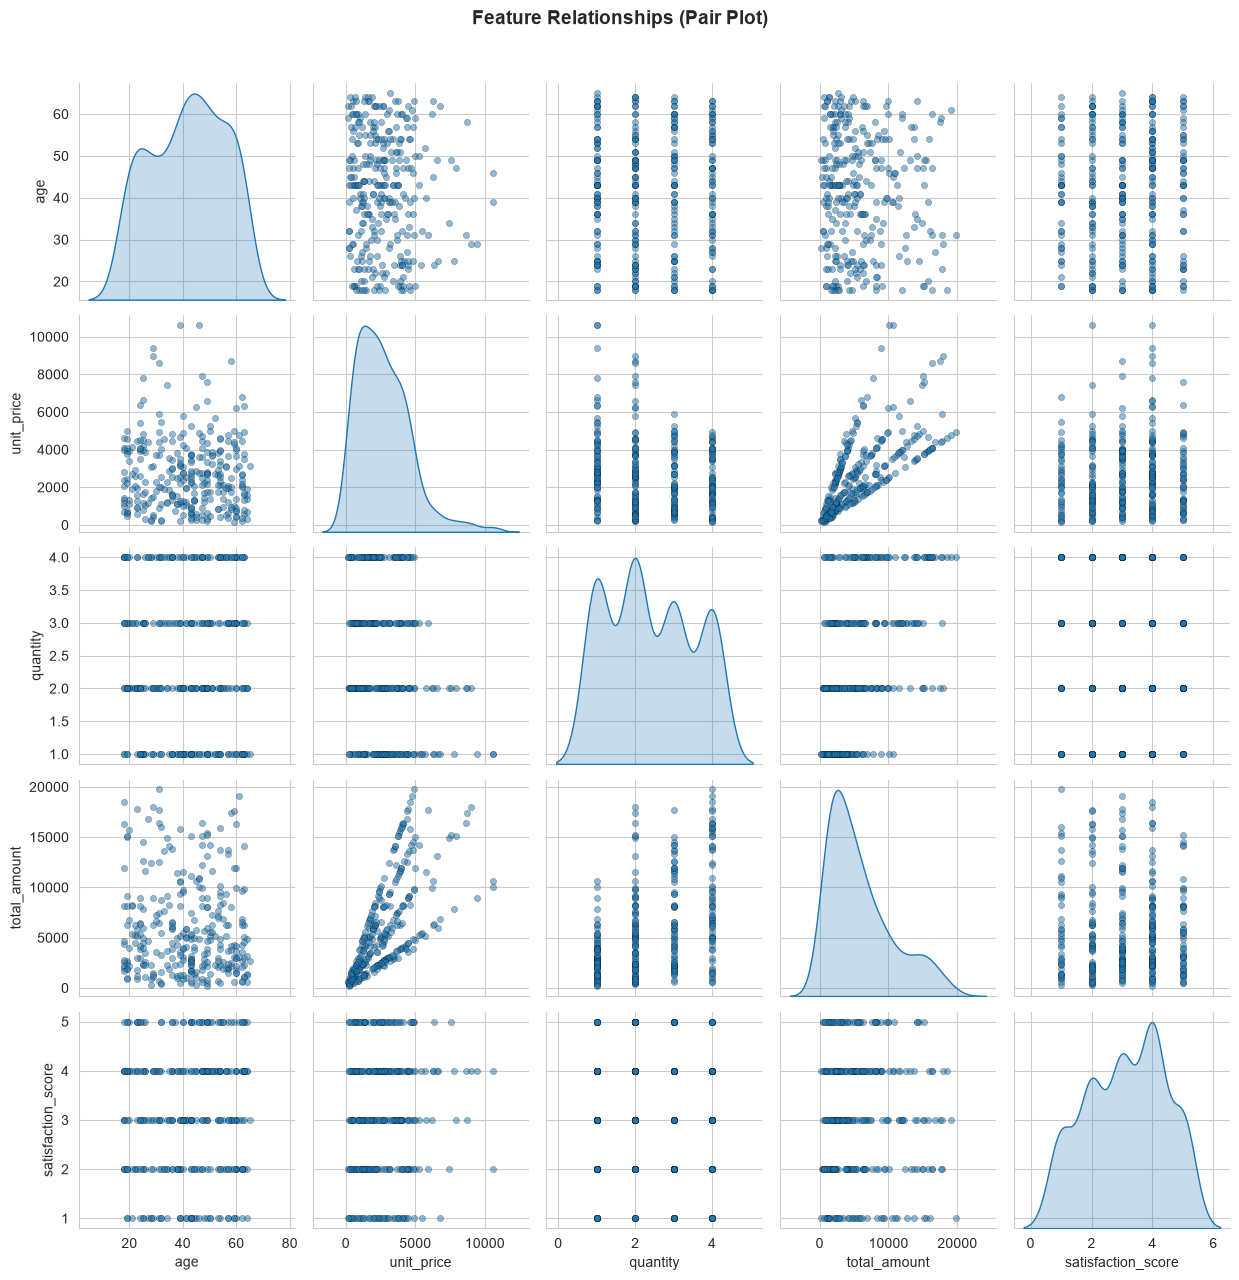

In [45]:
pair_cols = df[['age', 'unit_price', 'quantity', 'total_amount', 'satisfaction_score']].sample(300, random_state=42)

g = sns.pairplot(pair_cols, diag_kind='kde',
    plot_kws={'alpha': 0.5, 'edgecolor': 'black', 's': 20, 'linewidth': 0.3})
g.figure.suptitle('Feature Relationships (Pair Plot)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualizations/24_pairplot.png', dpi=100)
plt.show()

**Insight:** The pair plot shows relationships between all numeric features at once. Unit price and total amount are strongly linked. Other features show weaker connections.

## 11. Key Insights and Recommendations

### Main Findings

1. **Top categories:** Electronics and Home & Kitchen make the most sales. Stock these well.

2. **City performance:** Bigger cities like Karachi and Lahore bring more revenue. Focus marketing there.

3. **Customer segments:** K-Means found 3 groups - high spenders, regular buyers, and low spenders. Each needs a different approach.

4. **Payment preferences:** Cash on Delivery and mobile payments (JazzCash, EasyPaisa) are popular. Keep these options available.

5. **Mobile first:** Most orders come from mobile devices. The website must work great on phones.

6. **Discounts work:** Customers who get discounts tend to have higher satisfaction scores.

7. **Age is not a factor:** All age groups spend about the same. Do not limit marketing to one age group.

8. **Sales are right-skewed:** Most orders are small. Offering bundle deals could increase average order value.

### Recommendations

- **For high spenders:** Give them VIP status and early access to new products.
- **For low spenders:** Send targeted emails with small discounts to bring them back.
- **For all customers:** Make the mobile app faster and easier to use.
- **For inventory:** Keep more stock in Electronics and Home & Kitchen.
- **For marketing:** Run campaigns on weekdays when order volume is highest.

---

**End of Analysis**